# Regional fairness and proxy analysis

## Overview

This notebook investigates regional gaps in scholarship decisions. We compare past committee decisions and baseline model predictions for applicants from major centers and remote regions. Then we check whether other application details reveal region even when the region column is removed.

We will compare grant rates across academic-score bands and estimated qualification groups, then test individual features and all 127 feature combinations for regional information. The final proxy tables show hidden regional clues, feature sets with weak regional signals, and the smallest sets that reveal region strongly.

## Steps

1. **Past committee decisions: R-score bands** — compare historical grant rates across five academic-score bands.
2. **Past committee decisions: fairness metrics** — compare grants among applicants who qualify under our estimated rule
3. **Baseline predictions: fairness metrics** — compare predicted grants using the same qualification rules.
4. **Baseline predictions: R-score bands** — locate the model's regional gaps across academic-score bands.
5. **Proxy audit setup** — train a Random Forest to predict region from other application details.
6. **Each feature alone** — identify features that reveal region individually.
7. **Remove one feature at a time** — check whether removing one clue reduces region prediction.
8. **Remove several features together** — measure the regional signal remaining after several clues are removed.
9. **Try every feature combination** — evaluate all 127 non-empty feature sets.
10. **Interpret the feature sets** — examine hidden proxies, the largest sets below AUC 0.6, and minimal sets above AUC 0.95.
11. **Final proxy analysis: region leaks through other columns** — explain what the results imply for model inputs.

## Main findings

- **Committee R-score bands:** grant rates increase with R-score in both regions, but center applicants receive grants more often in every band. In band 4, the rates are **79.6% for center applicants versus 50.5% for remote applicants**. Even in the highest band, the rates are **98.1% versus 91.4%**.
- **Past committee decisions show a regional grant gap.** Among applicants qualified by our estimated rule, **90.87% in centers** received grants compared with **61.09% in remote regions**, even though similar shares qualify in each group.
- **The baseline also shows a regional selection gap.** It predicts grants for **46.80% of center applicants versus 27.76% of remote applicants**. Among estimated qualified applicants, the rates are **97.95% versus 66.67%**. Its overall grant rate of **39.05%** meets the budget but still leaves regional differences.
- **Baseline R-score bands:** the model selects nobody in the lowest two bands and everyone in the highest band. The regional gap appears in the middle: **20.2% center versus 0% remote** in band 3, and **99.8% versus 57.7%** in band 4. These broad bands compare similar score ranges without controlling for every other applicant characteristic.
- **Postal code and distance reveal region almost perfectly.** Their individual AUCs are **1.0000** and **0.9979**. Removing any one feature leaves region prediction nearly perfect.
- **Hidden proxies remain after removing location clues.** Without postal code and distance, the best remaining feature set reaches **AUC 0.8414**. Removing income as well leaves **0.8106**; also removing work hours reduces it to **0.5967**.
- **Some feature sets reveal much less regional information.** The largest displayed set below AUC 0.6 is **R-score + first-generation status + study program**, at **0.5967**. R-score alone is close to random guessing at **0.5139**.
- **The smallest strong leaking sets each contain one feature.** Postal code alone and distance alone exceed AUC 0.95; no additional feature is needed for either to reveal region strongly.


Historical grant rate (%) by R-score band:
region_group  center  remote
r_band                      
1 lowest         0.7     0.1
2               10.9     2.7
3               37.5    12.8
4               79.6    50.5
5 highest       98.1    91.4


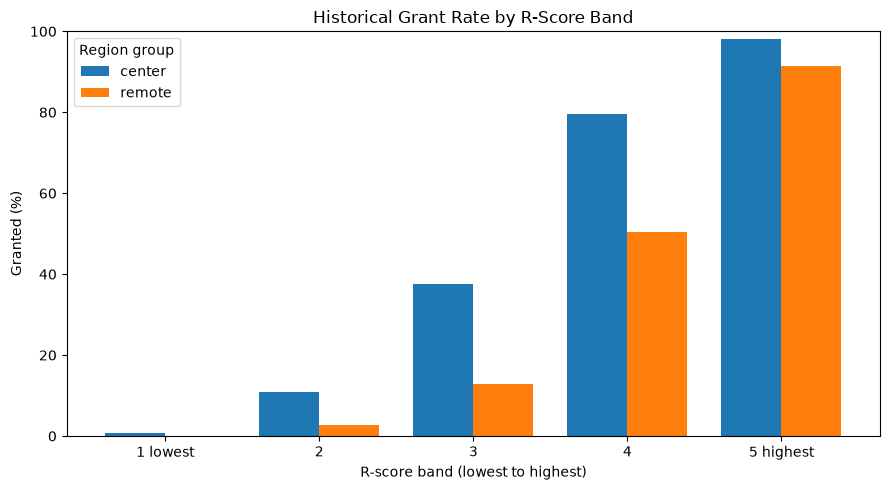

Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/analysis/fairness_and_bias_analysis/past_committee_decisions/r_band_analysis.png


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

raw_relative_path = Path("equialgo-participants/data/donnees_demandes.csv")
repository_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / raw_relative_path).is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError(f"Could not locate {raw_relative_path} from {Path.cwd()}")

analysis_dir = repository_root / "analysis" / "fairness_and_bias_analysis" / "past_committee_decisions"
analysis_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(repository_root / raw_relative_path)
remote_regions = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}
df["region_group"] = df["region_administrative"].apply(
    lambda region: "remote" if region in remote_regions else "center"
)

band_labels = ["1 lowest", "2", "3", "4", "5 highest"]
df["r_band"] = pd.qcut(df["cote_r_equivalent"], q=5, labels=band_labels)

table = (
    df.pivot_table(
        index="r_band",
        columns="region_group",
        values="decision_octroi",
        aggfunc="mean",
        observed=True,
    )
    .reindex(columns=["center", "remote"])
    .mul(100)
)

print("Historical grant rate (%) by R-score band:")
print(table.round(1).to_string())

ax = table.plot(kind="bar", figsize=(9, 5), width=0.78)
ax.set_title("Historical Grant Rate by R-Score Band")
ax.set_xlabel("R-score band (lowest to highest)")
ax.set_ylabel("Granted (%)")
ax.set_ylim(0, 100)
ax.legend(title="Region group")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
chart_path = analysis_dir / "r_band_analysis.png"
ax.figure.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart: {chart_path}")

## 2. Past committee decisions: fairness metrics


This notebook compares all applicants, remote applicants, and center applicants using one qualification formula. The proxy score is `(3 * R-score + 0.5 * income-need score + 0.5 * work-hours score) / 4`; the top 40% of scores qualify (60th percentile cutoff).

Metrics: **qualified / all applicants in group**; **granted / qualified applicants**; and **granted / unqualified applicants**. These are separate rates with different denominators. The grant decision is the historical `decision_octroi` label.

Qualification cutoff: 0.5496
        % qualified / all  % granted / qualified  % granted / unqualified
group                                                                    
All                 40.00                  78.55                    14.20
remote              41.38                  61.09                     3.45
center              39.08                  90.87                    21.09


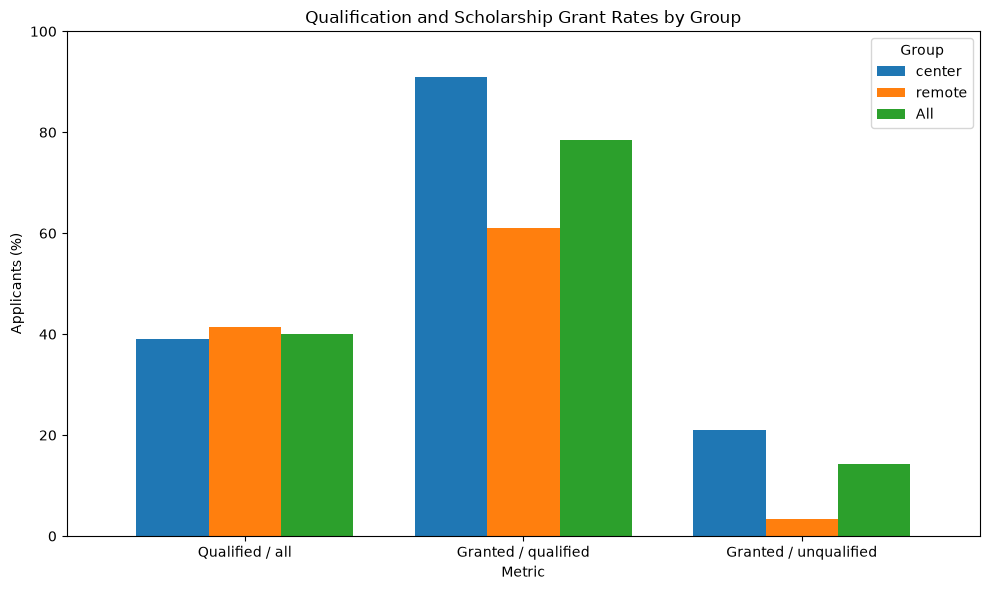

Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/analysis/fairness_and_bias_analysis/past_committee_decisions/fairness_metrics.png


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

raw_relative_path = Path("equialgo-participants/data/donnees_demandes.csv")
repository_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / raw_relative_path).is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError(f"Could not locate {raw_relative_path} from {Path.cwd()}")

analysis_dir = repository_root / "analysis" / "fairness_and_bias_analysis" / "past_committee_decisions"
analysis_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(repository_root / raw_relative_path)

remote_regions = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}
df["region_group"] = df["region_administrative"].apply(
    lambda region: "remote" if region in remote_regions else "center"
)

def minmax_scale(values):
    value_range = values.max() - values.min()
    if value_range == 0:
        return pd.Series(0.5, index=values.index)
    return (values - values.min()) / value_range

r_score = minmax_scale(df["cote_r_equivalent"])
income_need_score = 1 - minmax_scale(df["revenu_familial_estime"])
work_hours_score = minmax_scale(df["heures_travail_semaine"])
df["proxy_quality_score"] = (3 * r_score + 0.5 * income_need_score + 0.5 * work_hours_score) / 4
cutoff = df["proxy_quality_score"].quantile(0.60)
df["qualified_proxy"] = (df["proxy_quality_score"] >= cutoff).astype(int)

rows = []
for group_name in ["All", "remote", "center"]:
    group = df if group_name == "All" else df[df["region_group"] == group_name]
    qualified = group["qualified_proxy"] == 1
    unqualified = ~qualified
    rows.append(
        {
            "group": group_name,
            "% qualified / all": 100 * qualified.mean(),
            "% granted / qualified": 100 * group.loc[qualified, "decision_octroi"].mean(),
            "% granted / unqualified": 100 * group.loc[unqualified, "decision_octroi"].mean(),
        }
    )

table = pd.DataFrame(rows).set_index("group").round(2)
print(f"Qualification cutoff: {cutoff:.4f}")
print(table.to_string())

plot_data = table.T[["center", "remote", "All"]].rename(
    index={
        "% qualified / all": "Qualified / all",
        "% granted / qualified": "Granted / qualified",
        "% granted / unqualified": "Granted / unqualified",
    }
)
ax = plot_data.plot(kind="bar", figsize=(10, 6), width=0.78)
ax.set_title("Qualification and Scholarship Grant Rates by Group")
ax.set_xlabel("Metric")
ax.set_ylabel("Applicants (%)")
ax.set_ylim(0, 100)
ax.legend(title="Group")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
chart_path = analysis_dir / "fairness_metrics.png"
ax.figure.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart: {chart_path}")

## Short analysis

About 4 in 10 applicants qualify in both groups: 41.38% remote and 39.08% center. But among qualified applicants, scholarships went to 61.09% of remote applicants and 90.87% of center applicants. Among applicants not qualified by the proxy, the rates were 3.45% remote and 21.09% center. These are past grant decisions compared with our estimated qualification rule; they do not tell us for certain who truly deserved a scholarship or why the difference occurred.

## 3. Baseline predictions: fairness metrics


First map baseline decisions to evaluation applicants by `id_candidat`. Then compare predicted grant rates for All, remote, and center applicants using the qualification proxy, including the Genie/Sante study-bonus alternative. The evaluation set has no grant outcomes, so these are prediction selection rates, not accuracy or measured true fairness.

Mapped 4000 baseline predictions to evaluation applicants.

Baseline Predictions: Fairness Metrics
        % qualified / all  % baseline grants / all  % baseline grants / qualified  % baseline grants / unqualified
group                                                                                                             
All                 40.00                    39.05                          84.75                             8.58
remote              41.46                    27.76                          66.67                             0.21
center              39.00                    46.80                          97.95                            14.10


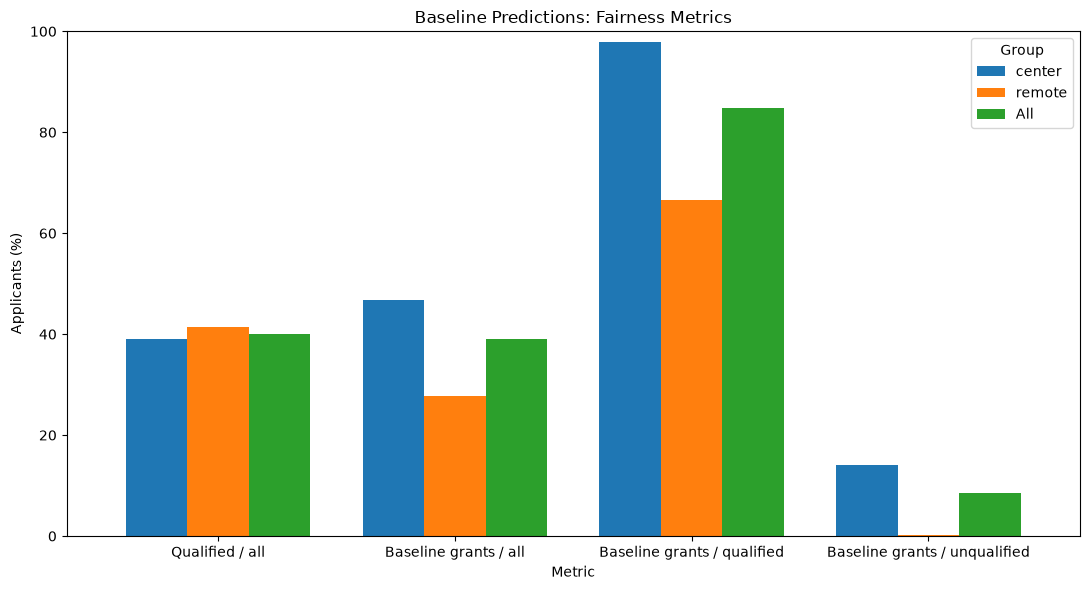

Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/analysis/fairness_and_bias_analysis/baseline_model_predictions/baseline_fairness_metrics.png

Baseline Predictions: Fairness Metrics with Study Bonus
        % qualified / all  % baseline grants / all  % baseline grants / qualified  % baseline grants / unqualified
group                                                                                                             
All                 40.00                    39.05                          75.00                            15.08
remote              40.97                    27.76                          61.02                             4.68
center              39.33                    46.80                          84.99                            22.03


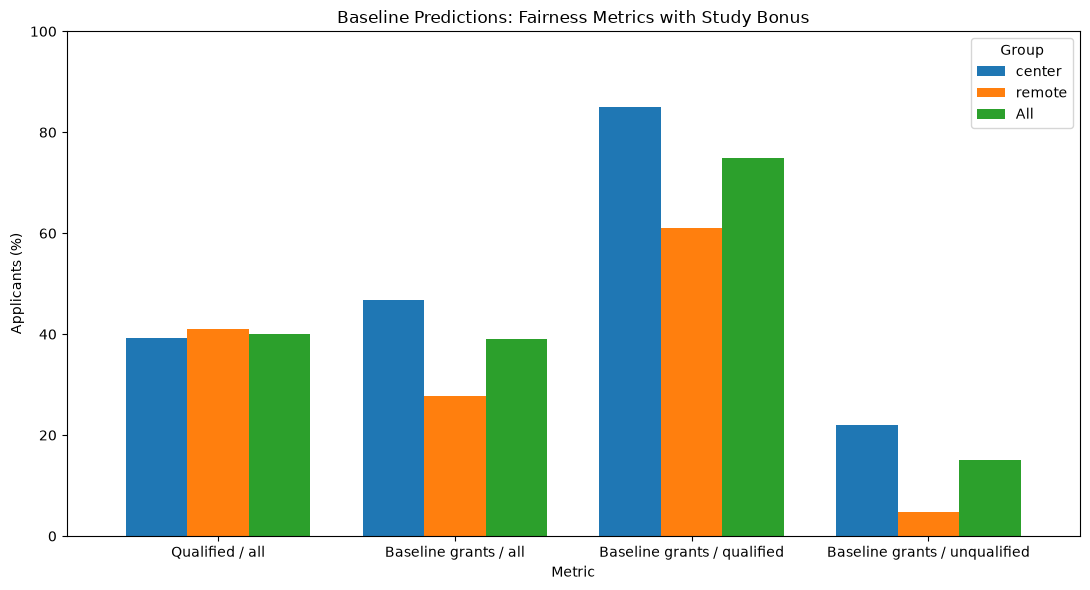

Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/analysis/fairness_and_bias_analysis/baseline_model_predictions/baseline_fairness_metrics_with_study_bonus.png


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

candidate_relative_path = Path("equialgo-participants/data/candidats_evaluation.csv")
repository_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / candidate_relative_path).is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError(f"Could not find {candidate_relative_path} from {Path.cwd()}")

analysis_dir = repository_root / "analysis" / "fairness_and_bias_analysis" / "baseline_model_predictions"
predictions_path = analysis_dir / "baseline_predictions.csv"
candidates = pd.read_csv(repository_root / candidate_relative_path)
predictions = pd.read_csv(predictions_path).rename(
    columns={"decision_octroi": "baseline_prediction"}
)

if candidates["id_candidat"].duplicated().any() or predictions["id_candidat"].duplicated().any():
    raise ValueError("Candidate and prediction IDs must be unique for one-to-one mapping.")
mapped = candidates.merge(
    predictions, on="id_candidat", how="outer", validate="one_to_one", indicator=True
)
if not mapped["_merge"].eq("both").all():
    raise ValueError("Prediction IDs do not match the evaluation candidate IDs.")
mapped = mapped.drop(columns="_merge")
print(f"Mapped {len(mapped)} baseline predictions to evaluation applicants.")

remote_regions = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}
mapped["region_group"] = mapped["region_administrative"].apply(
    lambda region: "remote" if region in remote_regions else "center"
)

def minmax_scale(values):
    value_range = values.max() - values.min()
    if value_range == 0:
        return pd.Series(0.5, index=values.index)
    return (values - values.min()) / value_range

r_score = minmax_scale(mapped["cote_r_equivalent"])
income_need_score = 1 - minmax_scale(mapped["revenu_familial_estime"])
hours_burden_score = minmax_scale(mapped["heures_travail_semaine"])

def build_metrics(qualified_column, title, chart_name):
    rows = []
    for group_name in ["All", "remote", "center"]:
        group = mapped if group_name == "All" else mapped[mapped["region_group"] == group_name]
        qualified = group[qualified_column] == 1
        unqualified = ~qualified
        rows.append(
            {
                "group": group_name,
                "% qualified / all": 100 * qualified.mean(),
                "% baseline grants / all": 100 * group["baseline_prediction"].mean(),
                "% baseline grants / qualified": 100 * group.loc[qualified, "baseline_prediction"].mean(),
                "% baseline grants / unqualified": 100 * group.loc[unqualified, "baseline_prediction"].mean(),
            }
        )

    table = pd.DataFrame(rows).set_index("group").round(2)
    print(f"\n{title}")
    print(table.to_string())
    plot_data = table.T[["center", "remote", "All"]].rename(
        index={
            "% qualified / all": "Qualified / all",
            "% baseline grants / all": "Baseline grants / all",
            "% baseline grants / qualified": "Baseline grants / qualified",
            "% baseline grants / unqualified": "Baseline grants / unqualified",
        }
    )
    ax = plot_data.plot(kind="bar", figsize=(11, 6), width=0.78)
    ax.set_title(title)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Applicants (%)")
    ax.set_ylim(0, 100)
    ax.legend(title="Group")
    ax.tick_params(axis="x", rotation=0)
    ax.figure.tight_layout()
    chart_path = analysis_dir / chart_name
    ax.figure.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved chart: {chart_path}")
    return table

mapped["qualified_proxy"] = (
    (3 * r_score + 0.5 * income_need_score + 0.5 * hours_burden_score) / 4
    >= ((3 * r_score + 0.5 * income_need_score + 0.5 * hours_burden_score) / 4).quantile(0.60)
).astype(int)
base_table = build_metrics(
    "qualified_proxy", "Baseline Predictions: Fairness Metrics", "baseline_fairness_metrics.png"
)

study_priority = mapped["programme_etudes"].isin({"Genie", "Sante"}).astype(int)
study_score = (3.5 * r_score + 0.5 * income_need_score + 0.5 * hours_burden_score + 0.5 * study_priority) / 5
mapped["qualified_with_study"] = (study_score >= study_score.quantile(0.60)).astype(int)
study_table = build_metrics(
    "qualified_with_study",
    "Baseline Predictions: Fairness Metrics with Study Bonus",
    "baseline_fairness_metrics_with_study_bonus.png",
)

## 4. Baseline predictions: R-score bands


Map each baseline prediction to its evaluation applicant by `id_candidat`, then compare predicted grant rates for remote and center applicants across five R-score bands. These are model selection rates, not observed scholarship outcomes.

Mapped 4000 baseline predictions to evaluation applicants.
Baseline predicted grant rate (%) by R-score band:
region_group  center  remote
r_band                      
1 lowest         0.0     0.0
2                0.0     0.0
3               20.2     0.0
4               99.8    57.7
5 highest      100.0   100.0


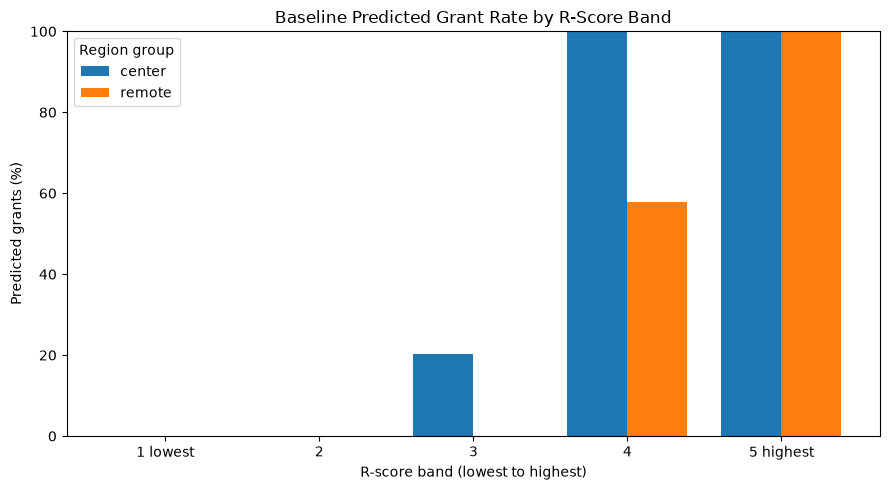

Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/analysis/fairness_and_bias_analysis/baseline_model_predictions/baseline_r_band_analysis.png


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

candidate_relative_path = Path("equialgo-participants/data/candidats_evaluation.csv")
repository_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / candidate_relative_path).is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError(f"Could not find {candidate_relative_path} from {Path.cwd()}")

analysis_dir = repository_root / "analysis" / "fairness_and_bias_analysis" / "baseline_model_predictions"
predictions_path = analysis_dir / "baseline_predictions.csv"
candidates = pd.read_csv(repository_root / candidate_relative_path)
predictions = pd.read_csv(predictions_path).rename(
    columns={"decision_octroi": "baseline_prediction"}
)

if candidates["id_candidat"].duplicated().any() or predictions["id_candidat"].duplicated().any():
    raise ValueError("Candidate and prediction IDs must be unique for one-to-one mapping.")
mapped = candidates.merge(
    predictions, on="id_candidat", how="outer", validate="one_to_one", indicator=True
)
if not mapped["_merge"].eq("both").all():
    raise ValueError("Prediction IDs do not match the evaluation candidate IDs.")
mapped = mapped.drop(columns="_merge")
print(f"Mapped {len(mapped)} baseline predictions to evaluation applicants.")

remote_regions = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}
mapped["region_group"] = mapped["region_administrative"].apply(
    lambda region: "remote" if region in remote_regions else "center"
)
band_labels = ["1 lowest", "2", "3", "4", "5 highest"]
mapped["r_band"] = pd.qcut(mapped["cote_r_equivalent"], q=5, labels=band_labels)

table = (
    mapped.pivot_table(
        index="r_band", columns="region_group", values="baseline_prediction",
        aggfunc="mean", observed=True,
    )
    .reindex(columns=["center", "remote"])
    .mul(100)
)
print("Baseline predicted grant rate (%) by R-score band:")
print(table.round(1).to_string())

ax = table.plot(kind="bar", figsize=(9, 5), width=0.78)
ax.set_title("Baseline Predicted Grant Rate by R-Score Band")
ax.set_xlabel("R-score band (lowest to highest)")
ax.set_ylabel("Predicted grants (%)")
ax.set_ylim(0, 100)
ax.legend(title="Region group")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
chart_path = analysis_dir / "baseline_r_band_analysis.png"
ax.figure.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart: {chart_path}")

# Proxy Feature Audit

**Question:** if we delete the region column, can the other columns still reveal where an applicant lives?

**How we test it:** train a model to guess *Remote vs Centre* from the other columns, then measure how well it guesses.

**AUC in plain English:** 0.5 means random guessing (no regional signal). 1.0 means it tells Remote from Centre perfectly (full leak).

**Steps**
1. Each column alone
2. Drop one column at a time
3. Grid search over every combination of columns
4. The three groups: hidden proxies, largest safe sets, minimal leaking sets

This is an association check, not proof that a column causes unfair decisions.

## 0. Setup

Loads the 10,000 historical applications and builds the target (1 = Remote, 0 = Centre).
The region column itself is **not** a feature. Same Random Forest, same 70/30 split for every test.

Two settings to change if needed:
- `TOP_N`: how many rows to show in each list.
- `RECOMPUTE_GRID`: set to `False` to reload the saved grid instead of retraining 127 models.

In [6]:
from itertools import combinations
from pathlib import Path

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

TOP_N = 5               # rows shown per list
RECOMPUTE_GRID = True   # False = reload proxy_grid.csv instead of retraining 127 models

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 250)

# Find the repo root by walking up until the data file is found
raw_relative_path = Path("equialgo-participants/data/donnees_demandes.csv")
repository_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / raw_relative_path).is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError(f"Could not locate {raw_relative_path} from {Path.cwd()}")

OUT_DIR = repository_root / "analysis" / "proxy_analysis" / "proxy_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(repository_root / raw_relative_path)

# Target: 1 = Remote region, 0 = Centre
REMOTE = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}
y = df["region_administrative"].isin(REMOTE).astype(int)

# Features: everything except the region itself, the ID and the committee decision
num = [
    "cote_r_equivalent",
    "revenu_familial_estime",
    "heures_travail_semaine",
    "distance_domicile_campus_km",
    "premiere_generation_universitaire",
]
cat = ["programme_etudes", "code_postal_3"]
all_cols = num + cat

X_tr, X_te, y_tr, y_te = train_test_split(
    df[all_cols], y, test_size=0.3, random_state=42, stratify=y
)


def auc_with(cols):
    """Train on the selected columns and return the test AUC for predicting Remote."""
    cats = [c for c in cols if c in cat]
    nums = [c for c in cols if c in num]
    prep = ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), cats)] if cats else [],
        remainder="passthrough",
    )
    model = Pipeline([
        ("prep", prep),
        ("rf", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1
        )),
    ])
    selected = cats + nums
    model.fit(X_tr[selected], y_tr)
    return roc_auc_score(y_te, model.predict_proba(X_te[selected])[:, 1])


def strength(auc):
    """Plain-English label for an AUC."""
    if auc >= 0.95:
        return "near-perfect proxy"
    if auc >= 0.75:
        return "strong proxy"
    if auc >= 0.60:
        return "moderate proxy"
    return "weak / not a proxy"

## 1. Each column alone

Train the model on **one column only** and see how well it guesses the region.
A high AUC means that column gives away the region by itself.

In [7]:
single = pd.DataFrame(
    [{"column": c, "auc": auc_with([c])} for c in all_cols]
).sort_values("auc", ascending=False).reset_index(drop=True)
single["strength"] = single["auc"].apply(strength)

print(single.round(4).to_string(index=False))
single.round(4).to_csv(OUT_DIR / "proxy_single_column.csv", index=False)

                           column    auc           strength
                    code_postal_3 1.0000 near-perfect proxy
      distance_domicile_campus_km 0.9979 near-perfect proxy
           heures_travail_semaine 0.8015       strong proxy
           revenu_familial_estime 0.6688     moderate proxy
premiere_generation_universitaire 0.5831 weak / not a proxy
                 programme_etudes 0.5567 weak / not a proxy
                cote_r_equivalent 0.5139 weak / not a proxy


## 2. Drop one column at a time

Train on **all columns**, then remove one column and see how much the AUC falls.
A big drop means the model needed that column. A tiny drop means the other columns cover for it,
which does **not** mean the column is harmless.

In [8]:
full_auc = auc_with(all_cols)
rows = [{"column": "ALL columns", "auc": full_auc, "auc_drop": 0.0}]

for c in all_cols:
    a = auc_with([x for x in all_cols if x != c])
    rows.append({"column": f"without {c}", "auc": a, "auc_drop": full_auc - a})

drop_one = pd.DataFrame(rows)
print(drop_one.round(4).to_string(index=False))
drop_one.round(4).to_csv(OUT_DIR / "proxy_drop_one.csv", index=False)

                                   column    auc  auc_drop
                              ALL columns 0.9998    0.0000
                without cote_r_equivalent 0.9999   -0.0000
           without revenu_familial_estime 0.9999   -0.0000
           without heures_travail_semaine 0.9998    0.0000
      without distance_domicile_campus_km 1.0000   -0.0002
without premiere_generation_universitaire 0.9998    0.0000
                 without programme_etudes 0.9999   -0.0000
                    without code_postal_3 0.9983    0.0015


### 2b. Drop several columns together

Remove the strongest carriers step by step to see how much signal is left.

In [9]:
group_drops = [
    ["code_postal_3", "distance_domicile_campus_km"],
    ["code_postal_3", "distance_domicile_campus_km", "revenu_familial_estime"],
    ["code_postal_3", "distance_domicile_campus_km", "revenu_familial_estime",
     "heures_travail_semaine"],
]

rows = []
for drop in group_drops:
    keep = [c for c in all_cols if c not in drop]
    rows.append({"removed": ", ".join(drop), "n_removed": len(drop), "auc_left": auc_with(keep)})

drop_groups = pd.DataFrame(rows)
print(drop_groups.round(4).to_string(index=False))
drop_groups.round(4).to_csv(OUT_DIR / "proxy_drop_groups.csv", index=False)

                                                                                   removed  n_removed  auc_left
                                                code_postal_3, distance_domicile_campus_km          2    0.8414
                        code_postal_3, distance_domicile_campus_km, revenu_familial_estime          3    0.8106
code_postal_3, distance_domicile_campus_km, revenu_familial_estime, heures_travail_semaine          4    0.5967


## 3. Grid search over every combination

With 7 columns there are 2^7 - 1 = **127** non-empty combinations. We train one model per combination
and record its AUC. This shows which sets of columns leak the region and which stay close to random.

It takes a few minutes. Results are saved to `proxy_grid.csv`.

In [10]:
grid_path = OUT_DIR / "proxy_grid.csv"

if RECOMPUTE_GRID or not grid_path.is_file():
    total = 2 ** len(all_cols) - 1
    grid_rows = []
    for size in range(1, len(all_cols) + 1):
        for subset in combinations(all_cols, size):
            grid_rows.append({
                "columns": ", ".join(subset),
                "n": size,
                "auc": auc_with(list(subset)),
            })
            if len(grid_rows) % 10 == 0 or len(grid_rows) == total:
                print(f"{len(grid_rows)}/{total} done")
    grid = pd.DataFrame(grid_rows).sort_values("auc", ascending=False).reset_index(drop=True)
    grid.round(4).to_csv(grid_path, index=False)
else:
    grid = pd.read_csv(grid_path)

print(f"\n{len(grid)} combinations. Saved to {grid_path}")

10/127 done
20/127 done
30/127 done
40/127 done
50/127 done
60/127 done
70/127 done
80/127 done
90/127 done
100/127 done
110/127 done
120/127 done
127/127 done

127 combinations. Saved to /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/analysis/proxy_analysis/proxy_outputs/proxy_grid.csv


## 4. The three groups

Top few of each list (set `TOP_N` in the setup cell). Postal code and distance leak the region on their own,
so any set that contains one of them scores about 1.0 and says nothing new. The lists below remove that noise:

1. **Hidden proxies:** the strongest leaks among sets that do **not** use postal code or distance.
   This shows how much region signal is left in the other columns.
2. **Largest safe sets:** the biggest sets of columns that still stay close to random (AUC below 0.6).
   These are candidate model inputs.
3. **Minimal leaking sets:** sets with AUC above 0.95 where no smaller part already leaks.
   This shows the true minimum culprits.

In [11]:
grid = grid.copy()
grid["auc"] = grid["auc"].round(4)
col_sets = grid["columns"].str.split(", ").apply(frozenset)
OBVIOUS = {"code_postal_3", "distance_domicile_campus_km"}

# 1. Hidden proxies: strongest leaks without postal code or distance
no_obvious = grid[col_sets.apply(lambda s: not (s & OBVIOUS))]
hidden_proxies = no_obvious.sort_values(["auc", "n"], ascending=[False, True]).head(TOP_N)

# 2. Largest safe sets: most columns while AUC stays below 0.6
safe_sets = (
    grid[grid["auc"] < 0.6]
    .sort_values(["n", "auc"], ascending=[False, True])
    .head(TOP_N)
)

# 3. Minimal leaking sets: AUC > 0.95 and no smaller subset already leaks
leaking = grid[grid["auc"] > 0.95]
leaking_sets = list(col_sets[leaking.index])
is_minimal = [not any(other < s for other in leaking_sets) for s in leaking_sets]
minimal_leaking = (
    leaking[is_minimal]
    .sort_values(["n", "auc"], ascending=[True, False])
    .head(TOP_N)
)

for title, table, filename in [
    ("HIDDEN PROXIES (strongest leaks without postal code or distance)",
     hidden_proxies, "proxy_hidden_proxies.csv"),
    ("LARGEST SAFE SETS (most columns, AUC < 0.6)", safe_sets, "proxy_safe_sets.csv"),
    ("MINIMAL LEAKING SETS (AUC > 0.95, no smaller subset leaks)",
     minimal_leaking, "proxy_minimal_leaking.csv"),
]:
    print(f"\n{title}")
    print(table.round(4).to_string(index=False))
    table.round(4).to_csv(OUT_DIR / filename, index=False)

print(f"\nBest AUC without postal code or distance: {no_obvious['auc'].max():.4f}")
print(f"All tables saved in {OUT_DIR}")


HIDDEN PROXIES (strongest leaks without postal code or distance)
                                                                                                               columns  n    auc
cote_r_equivalent, revenu_familial_estime, heures_travail_semaine, premiere_generation_universitaire, programme_etudes  5 0.8414
                   revenu_familial_estime, heures_travail_semaine, premiere_generation_universitaire, programme_etudes  4 0.8388
                  cote_r_equivalent, revenu_familial_estime, heures_travail_semaine, premiere_generation_universitaire  4 0.8370
                                   cote_r_equivalent, revenu_familial_estime, heures_travail_semaine, programme_etudes  4 0.8335
                                                      revenu_familial_estime, heures_travail_semaine, programme_etudes  3 0.8319

LARGEST SAFE SETS (most columns, AUC < 0.6)
                                                               columns  n    auc
cote_r_equivalent, premiere_genera